## 1. Prep Data for Combined UMAP

In [1]:
import pandas as pd

In [11]:
STRAT_XY_PATH = "../real_vase_data/profiles_stratified_120526.parquet"
ALL_REAL_XY_PATH = "../real_vase_data/all_profiles_120526.parquet"
GAME_XY_PATH = "../file_processing/processed/xy_data.parquet"
METADATA_PATH = "../real_vase_data/master_metadata.csv"
AI_GAME_XY_PATH = "../ai_beauty/pca_llm_results/processed/ai_xy_data.parquet"

In [3]:
all_real_xy = pd.read_parquet(ALL_REAL_XY_PATH)
strat_xy_df = pd.read_parquet(STRAT_XY_PATH)

In [4]:
strat_gpp_nos = strat_xy_df["gpp_no"].unique()
real_xy_df = all_real_xy[all_real_xy["gpp_no"].isin(strat_gpp_nos)]
print(f"Real xy df shape: {real_xy_df.shape}")
print(f"Number of unique gpp_no in real xy df: {real_xy_df['gpp_no'].nunique()}")

Real xy df shape: (13288750, 4)
Number of unique gpp_no in real xy df: 53155


In [5]:

game_xy_df = pd.read_parquet(GAME_XY_PATH)

real_xy_df.rename(columns={'gpp_no': 'vase_id'}, inplace=True)

game_xy_df["vase_id"] = (
    game_xy_df["participant_id"].astype(str)
    + "::"
    + game_xy_df["generation_key"].astype(str)
    + "::"
    + game_xy_df["vase"].astype(str)
)

In [6]:
real_xy_df['source'] = 'real'
real_xy_df.head()

,vase_id,x,y,point_order,source
0,amph_1002176,-0.012187,1.5,0,real
1,amph_1002176,0.025235,1.5,1,real
2,amph_1002176,0.062658,1.5,2,real
3,amph_1002176,0.100081,1.5,3,real
4,amph_1002176,0.137504,1.5,4,real


In [7]:
game_xy_df['source'] = 'game'
game_xy_df.head()

,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,vase_id,source
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game


In [8]:
# Filter so parent vases are excluded from the UMAP projection
game_xy_df = game_xy_df[game_xy_df['is_parent_vase'] != True]

In [12]:
ai_xy_df = pd.read_parquet(AI_GAME_XY_PATH)
ai_xy_df['source'] = 'ai_game'
ai_xy_df.head()

,generation_key,vase,x,y,point_index,is_selected_vase,is_parent_vase,participant_id,session_id,play_counter,...,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,session_started_at,timestamp,source_file,source
0,round_0_gen_1,vase_1,-0.000167,1.605543,1,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,...,69,5000,0.0164,1558,82,completed,1.779840e+06,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
1,round_0_gen_1,vase_1,0.049104,1.605331,2,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,...,69,5000,0.0164,1558,82,completed,1.779840e+06,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
2,round_0_gen_1,vase_1,0.098312,1.605205,3,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,...,69,5000,0.0164,1558,82,completed,1.779840e+06,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
3,round_0_gen_1,vase_1,0.147359,1.605039,4,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,...,69,5000,0.0164,1558,82,completed,1.779840e+06,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
4,round_0_gen_1,vase_1,0.196230,1.604697,5,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,...,69,5000,0.0164,1558,82,completed,1.779840e+06,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game


In [13]:
ai_xy_df["vase_id"] = (
    ai_xy_df["participant_id"].astype(str)
    + "::"
    + ai_xy_df["generation_key"].astype(str)
    + "::"
    + ai_xy_df["vase"].astype(str)
)

ai_xy_df = ai_xy_df[ai_xy_df['is_parent_vase'] != True]

In [9]:
REAL_PC_PATH = "../file_processing/pca_csv/pca_scores.csv"
GAME_PC_PATH = "../file_processing/processed/pc_data.parquet"
AI_PC_PATH = "../ai_beauty/pca_llm_results/processed/ai_pc_data.parquet"

In [14]:
real_df = pd.read_csv(REAL_PC_PATH)
real_df.rename(columns={'gpp_no': 'vase_id'}, inplace=True)
real_df['source'] = 'real'
real_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'Real latent DataFrame shape: {real_df.shape}')
real_df.head()

Real latent DataFrame shape: (53152, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real


In [15]:
game_df = pd.read_parquet(GAME_PC_PATH)
game_df['source'] = 'game'
game_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'Game latent DataFrame shape: {game_df.shape}')
game_df.head()

Game latent DataFrame shape: (484200, 22)


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,source
0,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
1,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
2,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
3,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
4,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game


In [16]:
ai_df = pd.read_parquet(AI_PC_PATH)
ai_df['source'] = 'ai_game'
ai_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'AI latent DataFrame shape: {ai_df.shape}')
ai_df.head()

AI latent DataFrame shape: (199980, 23)


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,participant_id,session_id,play_counter,session_started_at,...,wall_time_s,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file,source
0,round_0_gen_1,vase_1,PC1,-3.374880,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,1.779840e+06,...,2.169575,69,5000,0.0164,1558,82,completed,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
1,round_0_gen_1,vase_2,PC1,-7.832178,True,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,1.779840e+06,...,2.169575,69,5000,0.0164,1558,82,completed,2026-05-27T00:06:24.054391,gpt_results.csv.gz,ai_game
2,round_0_gen_2,vase_1,PC1,-6.031124,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,1.779840e+06,...,2.220651,122,5000,0.0270,1558,135,completed,2026-05-27T00:06:26.302597,gpt_results.csv.gz,ai_game
3,round_0_gen_2,vase_2,PC1,-7.832178,True,True,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,1.779840e+06,...,2.220651,122,5000,0.0270,1558,135,completed,2026-05-27T00:06:26.302597,gpt_results.csv.gz,ai_game
4,round_0_gen_3,vase_1,PC1,-9.644491,False,False,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4,1,1.779840e+06,...,1.857240,98,5000,0.0222,1558,111,completed,2026-05-27T00:06:28.210096,gpt_results.csv.gz,ai_game


In [17]:
game_df["vase_id"] = (
    game_df["participant_id"].astype(str)
    + "::"
    + game_df["generation_key"].astype(str)
    + "::"
    + game_df["vase"].astype(str)
)

ai_df["vase_id"] = (
    ai_df["participant_id"].astype(str)
    + "::"
    + ai_df["generation_key"].astype(str)
    + "::"
    + ai_df["vase"].astype(str)
)

In [19]:
game_pc_wide = (
    game_df
    .pivot_table(index='vase_id', columns='pc_name', values='pc_value', aggfunc='first')
    .reset_index()
)
game_pc_wide.columns.name = None
game_pc_wide['source'] = 'game'
game_pc_wide['culture_general'] = None  # not available for game vases

ai_pc_wide = (
    ai_df
    .pivot_table(index='vase_id', columns='pc_name', values='pc_value', aggfunc='first')
    .reset_index()
)
ai_pc_wide.columns.name = None
ai_pc_wide['source'] = 'ai_game'
ai_pc_wide['culture_general'] = None  # not available for ai game vases

pc_cols = sorted([c for c in game_pc_wide.columns if c.startswith('PC')])
game_pc_wide = game_pc_wide[pc_cols + ['vase_id', 'culture_general', 'source']]
ai_pc_wide = ai_pc_wide[pc_cols + ['vase_id', 'culture_general', 'source']]

print(f'Game PC wide shape: {game_pc_wide.shape}')
print(f'AI PC wide shape:   {ai_pc_wide.shape}')
print(f'Real PC shape:      {real_df.shape}')
game_pc_wide.head()

Game PC wide shape: (80700, 9)
AI PC wide shape:   (33330, 9)
Real PC shape:      (53152, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source
0,7.679457,-6.946636,0.484075,-0.974251,4.121744,-3.594158,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...,None,game
1,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...,None,game
2,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...,None,game
3,9.789102,-3.732227,9.030363,7.960451,-1.850243,-0.781221,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...,None,game
4,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...,None,game


In [20]:
real_latent_df = real_df[[ c for c in real_df.columns if c.startswith('PC') ]]
real_latent_df['source'] = 'real'
real_latent_df['vase_id'] = real_df['vase_id']
real_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,real,af_1
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,real,af_10
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,real,af_101
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,real,af_102
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,real,af_103


In [21]:
game_latent_df = game_pc_wide[[ c for c in game_pc_wide.columns if c.startswith('PC') ]]
game_latent_df['source'] = 'game'
game_latent_df['vase_id'] = game_pc_wide['vase_id']
game_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,7.679457,-6.946636,0.484075,-0.974251,4.121744,-3.594158,game,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...
1,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,game,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...
2,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,game,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...
3,9.789102,-3.732227,9.030363,7.960451,-1.850243,-0.781221,game,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...
4,5.744613,0.207472,5.276123,1.719233,0.144714,2.052788,game,004af8cd-d2fb-47e8-a133-8b6ab244c3f1::round_0_...


In [22]:
ai_latent_df = ai_pc_wide[[ c for c in ai_pc_wide.columns if c.startswith('PC') ]]
ai_latent_df['source'] = 'ai_game'
ai_latent_df['vase_id'] = ai_pc_wide['vase_id']
ai_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,2.412726,5.543394,-4.415902,1.418405,-0.351305,2.216434,ai_game,002a7239-227b-4244-9ff7-6f8e7651ed3a::round_0_...
1,-0.329525,5.158806,-4.575806,-0.257563,5.454641,-3.497054,ai_game,002a7239-227b-4244-9ff7-6f8e7651ed3a::round_0_...
2,-0.329525,5.158806,-4.575806,-0.257563,5.454641,-3.497054,ai_game,002a7239-227b-4244-9ff7-6f8e7651ed3a::round_0_...
3,-4.818558,-2.525394,-3.349430,-3.754924,6.329767,-5.356411,ai_game,002a7239-227b-4244-9ff7-6f8e7651ed3a::round_0_...
4,-1.996117,-5.839512,1.132324,-4.844931,5.922229,-6.266003,ai_game,002a7239-227b-4244-9ff7-6f8e7651ed3a::round_0_...


In [23]:
latent_df = pd.concat([real_latent_df, game_latent_df, ai_latent_df], ignore_index=True)
print(f'Combined latent DataFrame shape: {latent_df.shape}')
print(latent_df['source'].value_counts())
latent_df.head()

Combined latent DataFrame shape: (167182, 8)
source
game       80700
real       53152
ai_game    33330
Name: count, dtype: int64


,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,real,af_1
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,real,af_10
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,real,af_101
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,real,af_102
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,real,af_103


## 2. Optimise UMAP Projection

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.manifold import trustworthiness
from tqdm import tqdm

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# [LATENT] Process all latent dimensions into an array for UMAP
latent_cols = [ c for c in latent_df.columns if c.startswith('PC') ]
latent_array = latent_df[latent_cols].values
print(f'Latent array shape: {latent_array.shape}')

Latent array shape: (167182, 6)


In [33]:
def build_xy_feature_matrix(df, id_col='vase_id', order_col='point_order'):
    rows, ids, sources = [], [], []
    for (vase_id, source), grp in df.groupby([id_col, 'source'], sort=False):
        grp_sorted = grp.sort_values(order_col) if order_col in grp.columns else grp
        x = grp_sorted['x'].to_numpy(dtype=np.float32)
        y = grp_sorted['y'].to_numpy(dtype=np.float32)
        rows.append(np.concatenate([x, y]))
        ids.append(vase_id)
        sources.append(source)
    return np.stack(rows), pd.DataFrame({'vase_id': ids, 'source': sources})

xy_matrix_real, meta_real = build_xy_feature_matrix(real_xy_df)
xy_matrix_game, meta_game = build_xy_feature_matrix(game_xy_df)
xy_matrix_ai, meta_ai = build_xy_feature_matrix(ai_xy_df)

# Toggle: use both sources or just game for testing
TEST_GAME_ONLY = False

if TEST_GAME_ONLY:
    xy_array = xy_matrix_game
    xy_meta_df = meta_game
else:
    xy_array = np.vstack([xy_matrix_real, xy_matrix_game, xy_matrix_ai])
    xy_meta_df = pd.concat([meta_real, meta_game, meta_ai], ignore_index=True)

print(f'XY feature matrix shape: {xy_array.shape}')
print(xy_meta_df['source'].value_counts())

XY feature matrix shape: (122785, 500)
source
real       53155
game       48420
ai_game    21210
Name: count, dtype: int64


In [27]:
def umap_calibration(latent_matrix, sample_size=15000, n_neighbors_test = [15, 50, 150, 200], min_dist_test = [0.01, 0.1, 0.5]):
    np.random.seed(42)
    indices = np.random.choice(latent_matrix.shape[0], sample_size, replace=False)
    X_sample = latent_matrix[indices]
    
    fig, axes = plt.subplots(len(n_neighbors_test), len(min_dist_test), figsize=(18, 18))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    best_score = 0
    best_params = {}
        
    for i, n_n in tqdm(enumerate(n_neighbors_test), total=len(n_neighbors_test)):
        for j, m_d in tqdm(enumerate(min_dist_test), total=len(min_dist_test)):
            print(f"   -> Testing: n_neighbors={n_n}, min_dist={m_d}")
            
            reducer = umap.UMAP(
                n_components=2, 
                n_neighbors=n_n, 
                min_dist=m_d, 
                metric='euclidean', 
                random_state=42
            )
            umap_coords = reducer.fit_transform(X_sample)
            
            # Trustworthiness measures to what extent the local structure is retained.
            # A score of 1.0 means the 2D map perfectly represents the true latent dimensions' local relationships.
            score = trustworthiness(X_sample, umap_coords, n_neighbors=n_n)
            
            if score > best_score:
                best_score = score
                best_params = {'n_neighbors': n_n, 'min_dist': m_d}
            
            ax = axes[i, j]
            ax.scatter(umap_coords[:, 0], umap_coords[:, 1], s=1, alpha=0.3, c='black')
            ax.set_title(f"n_neighbors: {n_n} | min_dist: {m_d}\nTrustworthiness: {score:.4f}", fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.suptitle("UMAP Hyperparameter Topologies (15k Sample)", fontsize=20, y=0.92)
    plt.savefig("umap_calibration_grid.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   MATHEMATICAL OPTIMUM: n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']} (Score: {best_score:.4f})")
    
    return best_params

In [29]:
n_neighbors_test = [150, 200, 300] 
min_dist_test = [0.01, 0.02, 0.05, 0.1, 0.5]

In [30]:
optimal_params = umap_calibration(xy_array, sample_size=15000, n_neighbors_test=n_neighbors_test, min_dist_test=min_dist_test)
print(f"Optimal UMAP Parameters: {optimal_params}")

  0%|          | 0/3 [00:00<?, ?it/s]/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


   -> Testing: n_neighbors=150, min_dist=0.01


/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Testing: n_neighbors=150, min_dist=0.02


/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

   -> Testing: n_neighbors=300, min_dist=0.1


/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Testing: n_neighbors=300, min_dist=0.5


100%|██████████| 3/3 [09:50<00:00, 196.90s/it]


   MATHEMATICAL OPTIMUM: n_neighbors=150, min_dist=0.01 (Score: 0.9242)
Optimal UMAP Parameters: {'n_neighbors': 150, 'min_dist': 0.01}


In [ ]:
# n_n_opt = optimal_params['n_neighbors']
# m_d_opt = optimal_params['min_dist']

In [31]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=200,
    min_dist=0.02,
    metric='euclidean',
    random_state=42,
)
embedding = reducer.fit_transform(xy_array) 
print('UMAP embedding shape:', embedding.shape)

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (122785, 2)


In [34]:
umap_x = embedding[:, 0]
umap_y = embedding[:, 1]
xy_meta_df = xy_meta_df.copy()
xy_meta_df['umap_x'] = umap_x
xy_meta_df['umap_y'] = umap_y
xy_meta_df.head()

,vase_id,source,umap_x,umap_y
0,amph_1002176,real,13.542836,4.071143
1,amph_310393_2,real,12.896677,4.802495
2,amph_310395_1,real,12.948102,4.914829
3,amph_310396,real,12.922070,4.827018
4,amph_st1479,real,12.788025,2.823941


In [35]:
master_df = pd.concat([real_df, game_df, ai_df], ignore_index=True)
print(f'Master DataFrame shape: {master_df.shape}')
print(master_df.columns)
master_df.head()

Master DataFrame shape: (737332, 42)
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'culture_general',
       'source', 'generation_key', 'vase', 'pc_name', 'pc_value',
       'is_selected_vase', 'is_parent_vase', 'selection_elapsed_time_s',
       'decision_time_ms', 'adjusted_selection_elapsed_time_s',
       'adjusted_decision_time_ms', 'rt_onset_correction_ms',
       'rt_calibration_status', 'rt_calibration_median_ms',
       'rt_calibration_trials_n', 'participant_id', 'session_id',
       'play_counter', 'metadata_schema_version', 'session_started_at',
       'session_duration_s', 'completion_status', 'phase', 'model', 'gen',
       'wall_time_s', 'rt_tokens', 'budget_tokens', 'budget_utilisation',
       'input_tokens', 'output_tokens', 'stop_reason', 'timestamp',
       'source_file'],
      dtype='str')


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source,generation_key,...,gen,wall_time_s,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Add the UMAP coordinates to the master DataFrame
# [XY] was: master_df.merge(latent_df[['vase_id', 'source', 'umap_x', 'umap_y']], ...)
master_df = master_df.merge(xy_meta_df[['vase_id', 'source', 'umap_x', 'umap_y']], on=['vase_id', 'source'], how='left')
print(f'Master DataFrame with UMAP shape: {master_df.shape}')
print(master_df.columns)
master_df.head()

Master DataFrame with UMAP shape: (737332, 44)
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'culture_general',
       'source', 'generation_key', 'vase', 'pc_name', 'pc_value',
       'is_selected_vase', 'is_parent_vase', 'selection_elapsed_time_s',
       'decision_time_ms', 'adjusted_selection_elapsed_time_s',
       'adjusted_decision_time_ms', 'rt_onset_correction_ms',
       'rt_calibration_status', 'rt_calibration_median_ms',
       'rt_calibration_trials_n', 'participant_id', 'session_id',
       'play_counter', 'metadata_schema_version', 'session_started_at',
       'session_duration_s', 'completion_status', 'phase', 'model', 'gen',
       'wall_time_s', 'rt_tokens', 'budget_tokens', 'budget_utilisation',
       'input_tokens', 'output_tokens', 'stop_reason', 'timestamp',
       'source_file', 'umap_x', 'umap_y'],
      dtype='str')


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source,generation_key,...,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file,umap_x,umap_y
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.302551,-0.738109
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.070203,1.833667
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.110246,6.335219
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.158931,5.513231
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.168776,-1.147401


## 3. Plot UMAP Projections

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np

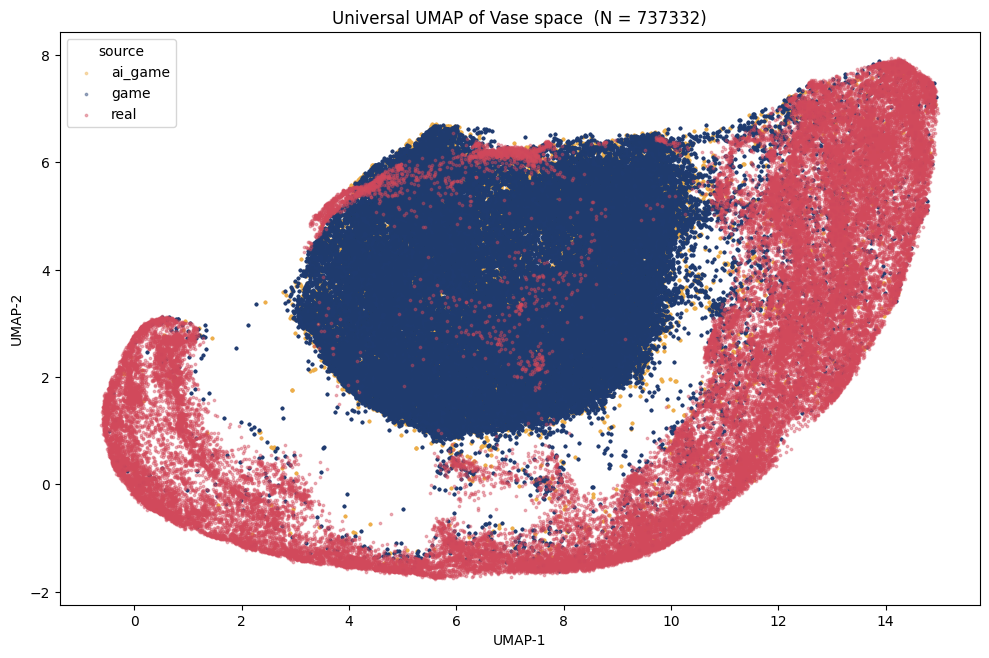

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = {'game': '#1f3b70', 'real': '#d1495b', 'ai_game': '#edae49'}
for source, sub in master_df.groupby('source'):
    ax.scatter(sub['umap_x'], sub['umap_y'], s=3, alpha=0.4, color=colors.get(source, 'gray'), label=source)
ax.legend(title='source')
ax.set_title(f'Universal UMAP of Vase space  (N = {len(master_df)})')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("figures/umap_universal.png", dpi=300, bbox_inches='tight')
plt.show()

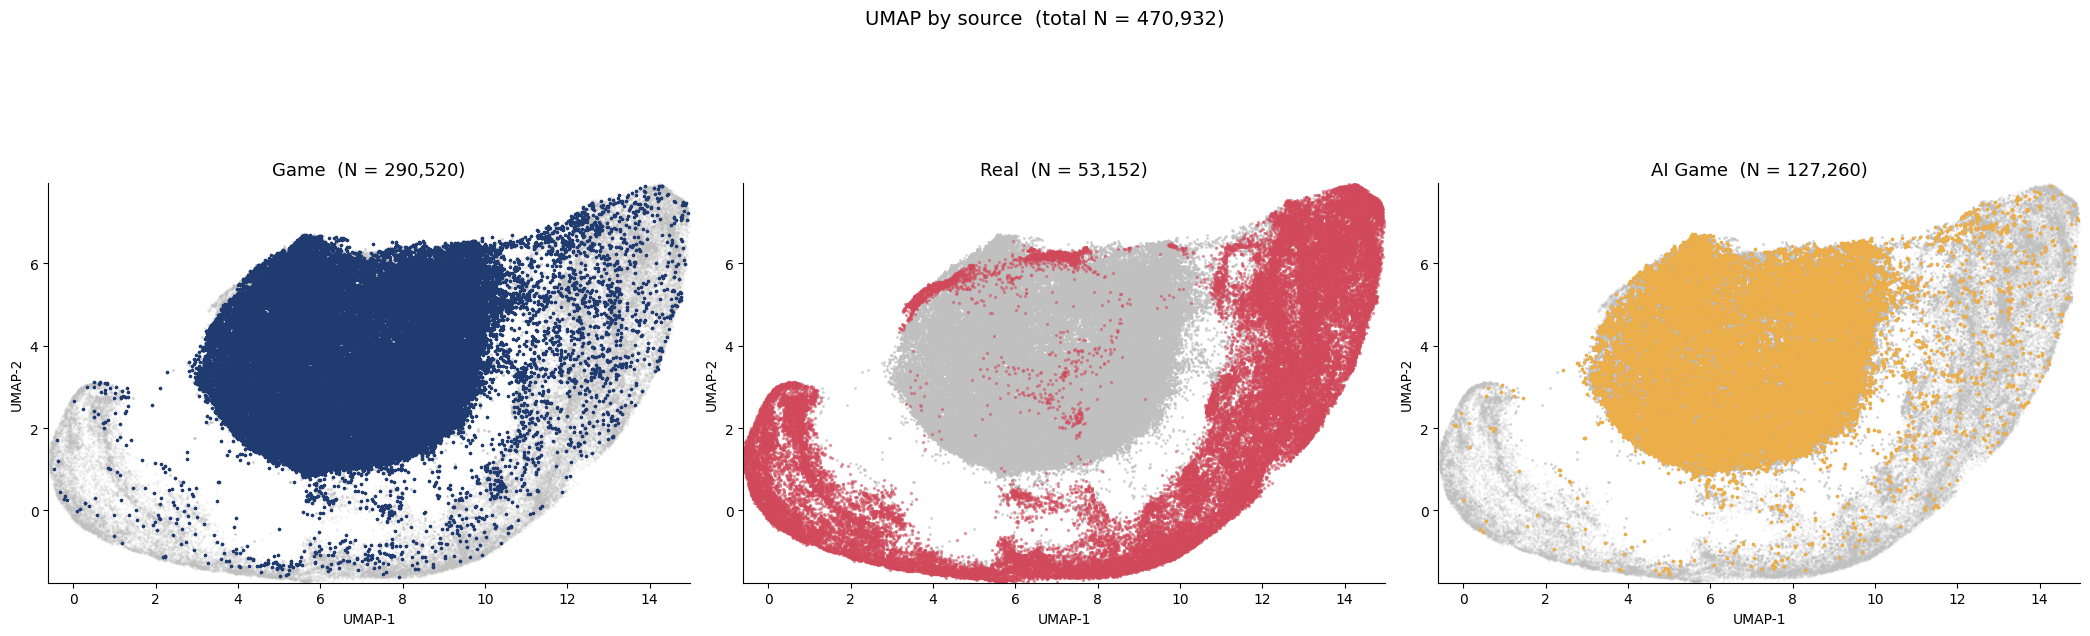

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
colors  = {'game': '#1f3b70', 'real': '#d1495b', 'ai_game': '#edae49'}
sources = ['game', 'real', 'ai_game']
labels  = ['Game', 'Real', 'AI Game']

# Pre-compute plot limits from all data so every panel shares the same axis range
_valid = master_df.dropna(subset=['umap_x', 'umap_y'])
x_lim = (_valid['umap_x'].min(), _valid['umap_x'].max())
y_lim = (_valid['umap_y'].min(), _valid['umap_y'].max())

for ax, source, label in zip(axes, sources, labels):
    sub = master_df[master_df['source'] == source].dropna(subset=['umap_x', 'umap_y'])

    # All points in grey
    ax.scatter(
        _valid['umap_x'], _valid['umap_y'],
        s=1, alpha=0.12, color='#c0c0c0', rasterized=True,
    )
    # Highlighted source in colour
    ax.scatter(
        sub['umap_x'], sub['umap_y'],
        s=2, alpha=0.45, color=colors[source], rasterized=True,
    )

    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_aspect('equal')
    ax.set_title(f'{label}  (N = {len(sub):,})', fontsize=13)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'UMAP by source  (total N = {len(_valid):,})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/umap_by_source.png", dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# Build normalized contour dictionary directly from XY profile tables.
real_xy_for_plot = real_xy_df.rename(columns={'gpp_no': 'vase_id'})[['vase_id', 'x', 'y']].copy()
real_xy_for_plot['source'] = 'real'

game_cols = ['vase_id', 'x', 'y'] + (['coord_order'] if 'coord_order' in game_xy_df.columns else [])
game_xy_for_plot = game_xy_df[game_cols].copy()
game_xy_for_plot['source'] = 'game'

xy_for_plot = pd.concat([real_xy_for_plot, game_xy_for_plot], ignore_index=True)

xy_for_plot.head()

,vase_id,x,y,source
0,amph_1002176,-0.012187,1.5,real
1,amph_1002176,0.025235,1.5,real
2,amph_1002176,0.062658,1.5,real
3,amph_1002176,0.100081,1.5,real
4,amph_1002176,0.137504,1.5,real


In [56]:
contours_by_key = {}
for (src, vase_id), grp in xy_for_plot.groupby(['source', 'vase_id'], sort=False):
    if 'coord_order' in grp.columns:
        grp = grp.sort_values('coord_order')

    x = grp['x'].to_numpy(dtype=float)
    y = grp['y'].to_numpy(dtype=float)
    if len(x) < 3:
        continue

    # Ensure closed polygon for clean fills.
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    # Normalize each vase profile to fit the draw cell consistently.
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    scale = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), 1e-9)
    x = x / scale
    y = y / scale

    contours_by_key[(src, vase_id)] = np.vstack([x, y])

In [57]:
# ai_xy_df was not included when contours_by_key was built — add ai_game contours now
for (src, vase_id), grp in ai_xy_df.groupby(['source', 'vase_id'], sort=False):
    x = grp['x'].to_numpy(dtype=float)
    y = grp['y'].to_numpy(dtype=float)
    if len(x) < 3:
        continue
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    scale = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), 1e-9)
    x /= scale
    y /= scale
    contours_by_key[(src, vase_id)] = np.vstack([x, y])

ai_keys = sum(1 for k in contours_by_key if k[0] == 'ai_game')
print(f"contours_by_key total: {len(contours_by_key):,}  (ai_game: {ai_keys:,})")

contours_by_key total: 122,785  (ai_game: 21,210)


In [58]:
def plot_vase_umap_grid(plot_df, contours, title=None, save_path=None, N=50,
                        source_colors=None):
    if source_colors is None:
        source_colors = {'real': '#d1495b', 'game': '#1f3b70', 'ai_game': '#edae49'}

    df = plot_df.dropna(subset=['umap_x', 'umap_y']).reset_index(drop=True)
    xs = df['umap_x'].to_numpy()
    ys = df['umap_y'].to_numpy()

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    cell_w = (x_max - x_min) / N
    cell_h = (y_max - y_min) / N

    col_idx = np.clip(((xs - x_min) / cell_w).astype(int), 0, N - 1)
    row_idx = np.clip(((ys - y_min) / cell_h).astype(int), 0, N - 1)

    cell_rep = {}
    for i, (ri, ci) in enumerate(zip(row_idx, col_idx)):
        cx = x_min + (ci + 0.5) * cell_w
        cy = y_min + (ri + 0.5) * cell_h
        d2 = (xs[i] - cx) ** 2 + (ys[i] - cy) ** 2
        if (ri, ci) not in cell_rep or d2 < cell_rep[(ri, ci)][0]:
            cell_rep[(ri, ci)] = (d2, i, cx, cy)

    draw_scale = cell_w * 0.30
    fig, ax = plt.subplots(figsize=(14, 14), dpi=150)
    ax.scatter(xs, ys, s=1, color='lightgrey', alpha=0.15, zorder=1, rasterized=True)

    for (ri, ci), (_, pt_idx, cx, cy) in cell_rep.items():
        row = df.iloc[pt_idx]
        src, vase_id = row['source'], row['vase_id']
        contour = contours.get((src, vase_id))
        if contour is None:
            continue
        ax.fill(cx + contour[0] * draw_scale, cy + contour[1] * draw_scale,
                color=source_colors.get(src, 'gray'), alpha=0.85, edgecolor='none', zorder=2)

    legend_handles = [Patch(facecolor=c, edgecolor='none', label=s)
                      for s, c in source_colors.items() if s in df['source'].values]
    ax.legend(handles=legend_handles, title='source', frameon=False)
    ax.set_aspect('equal')
    ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
    ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)
    ax.spines[['top', 'right']].set_visible(False)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

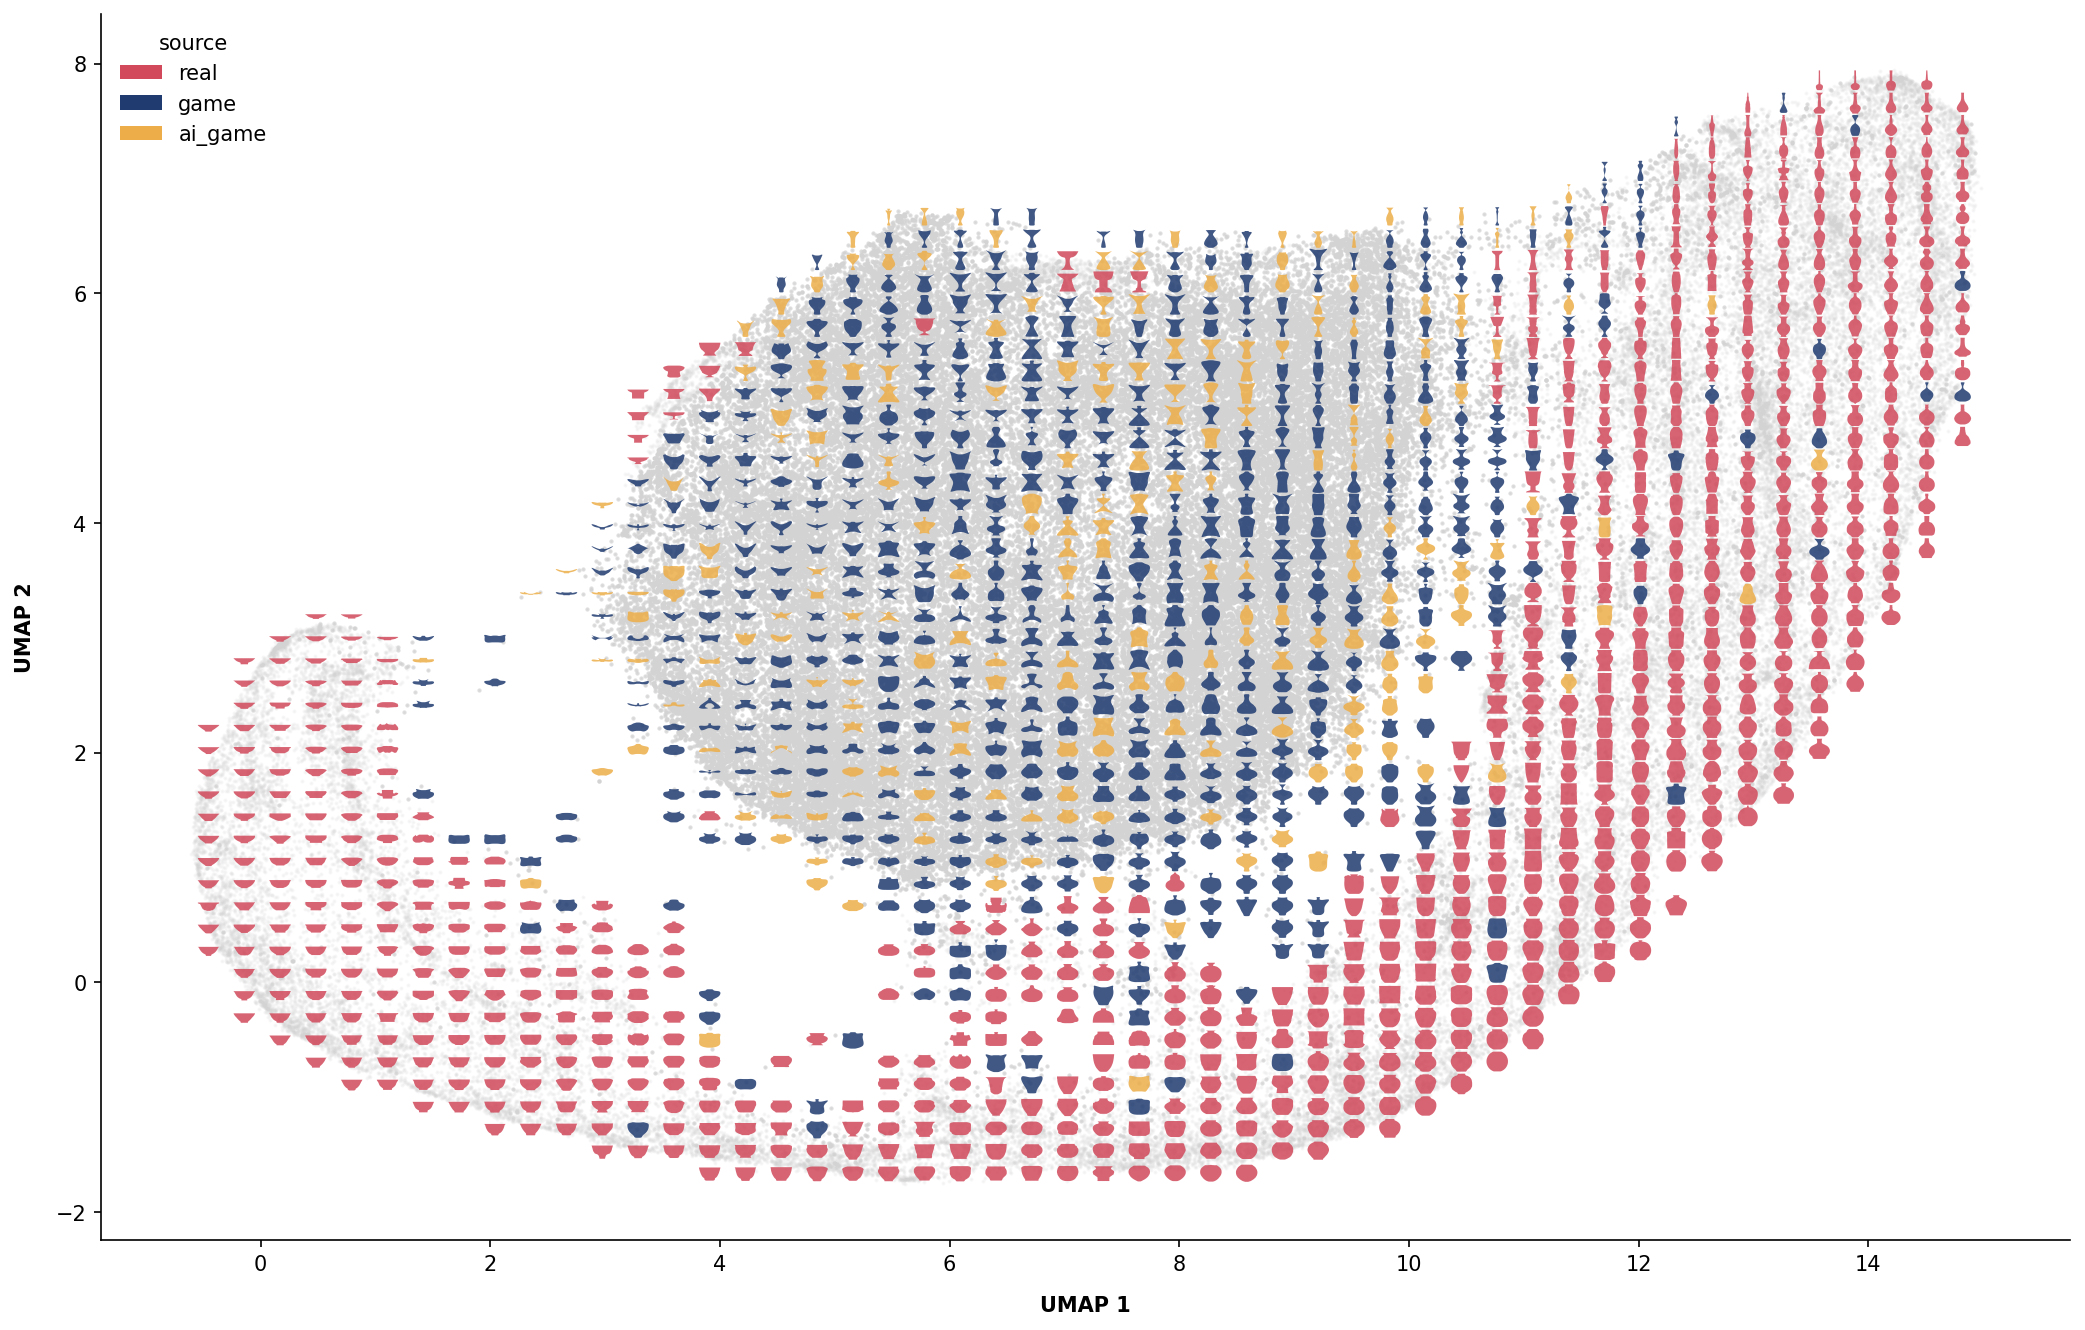

In [59]:
plot_vase_umap_grid(master_df, contours_by_key, save_path='vase_umap_grid.svg')

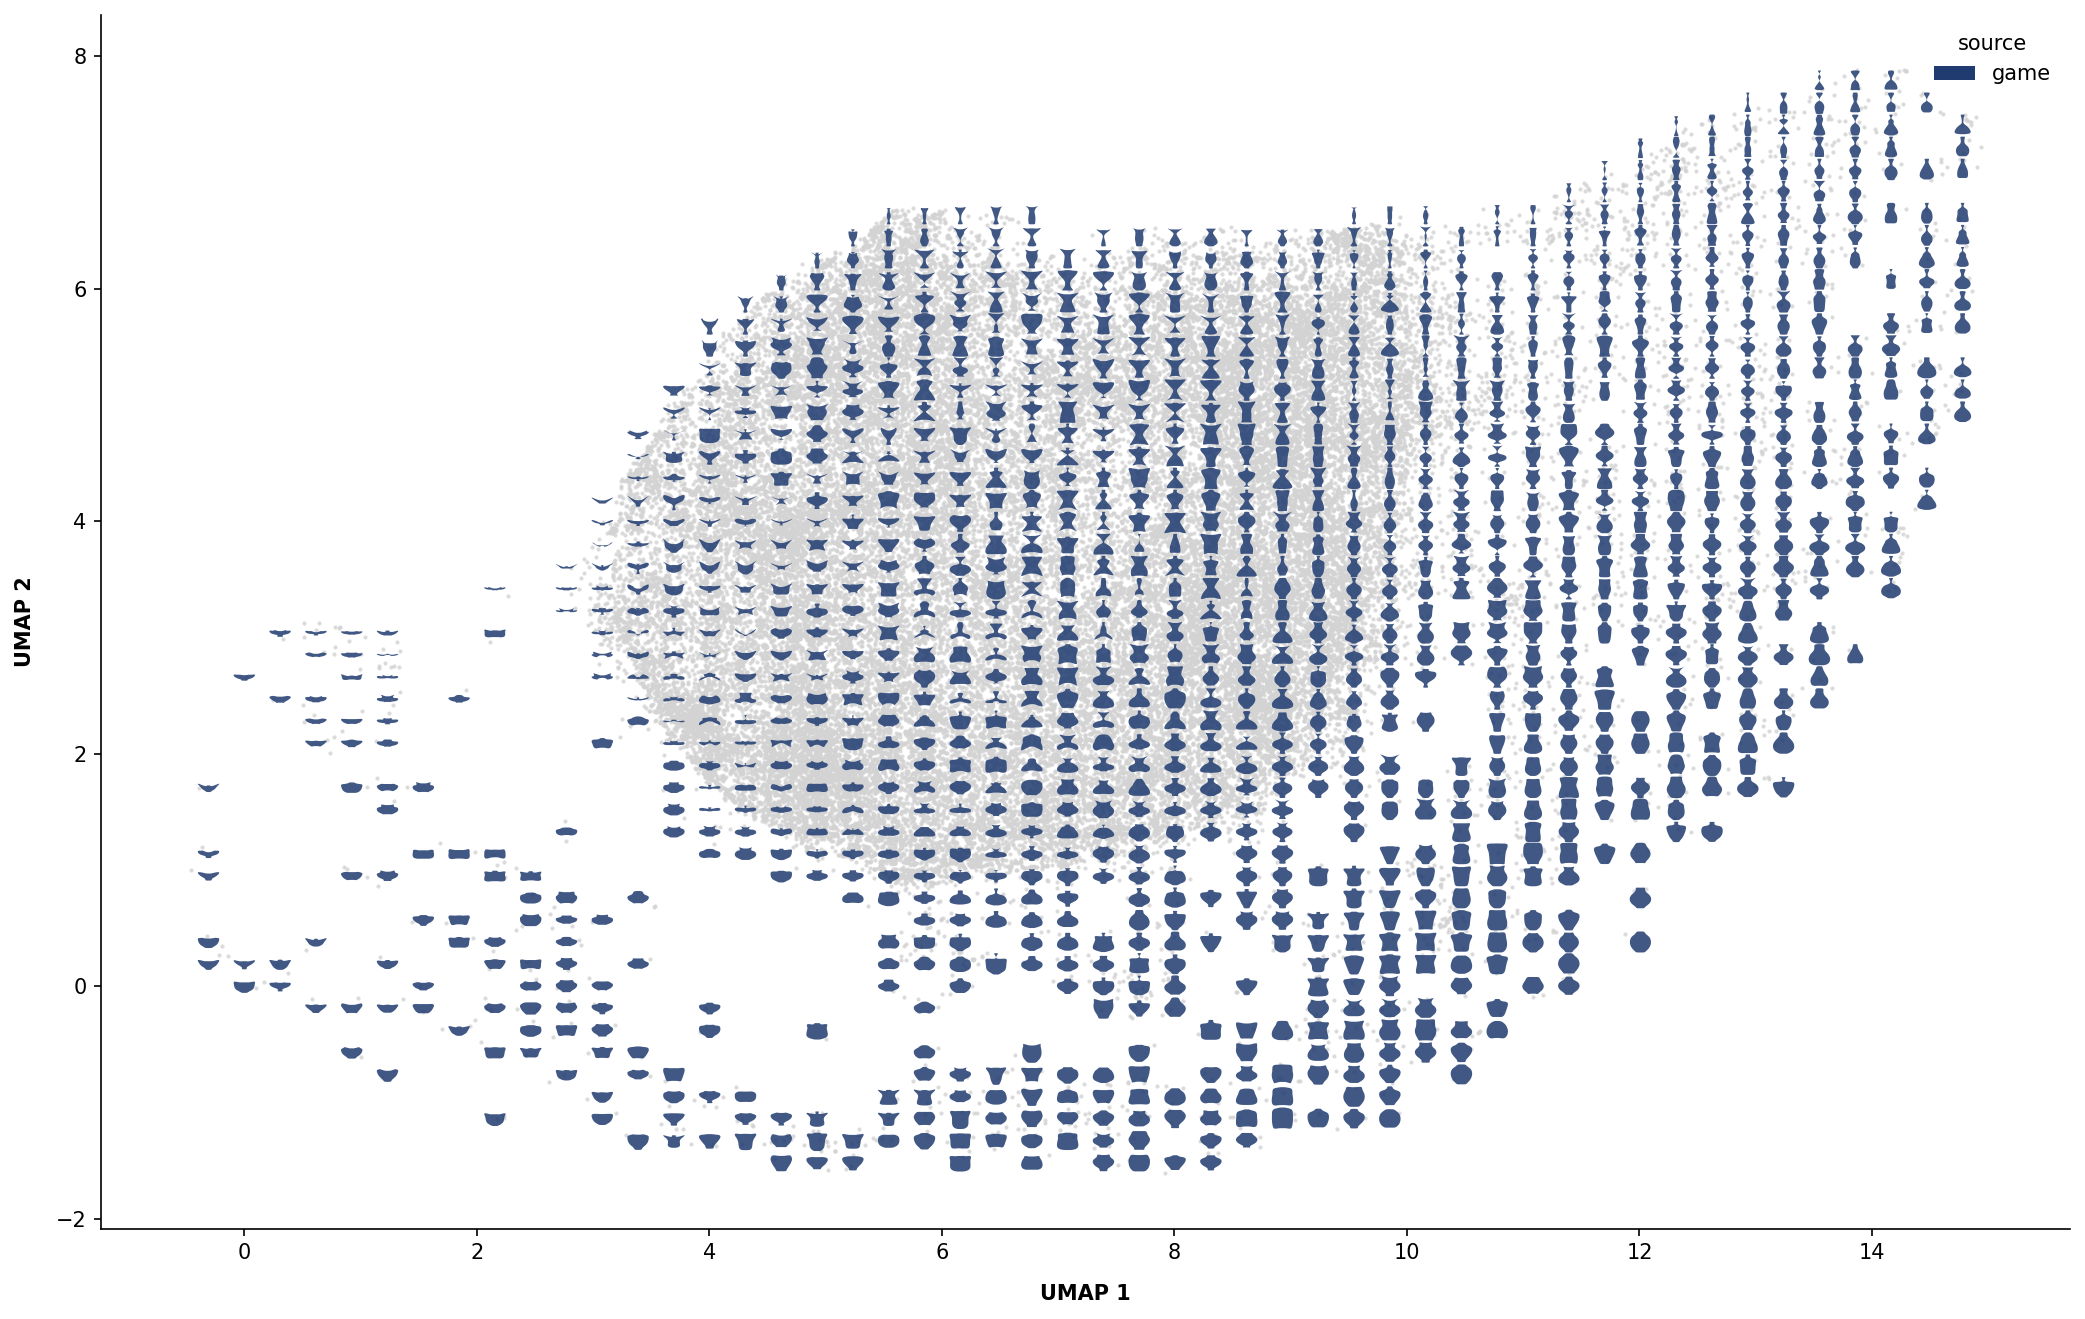

In [61]:
plot_vase_umap_grid(master_df[master_df['source'] == 'game'], contours_by_key, save_path='game_vase_umap_grid.svg')

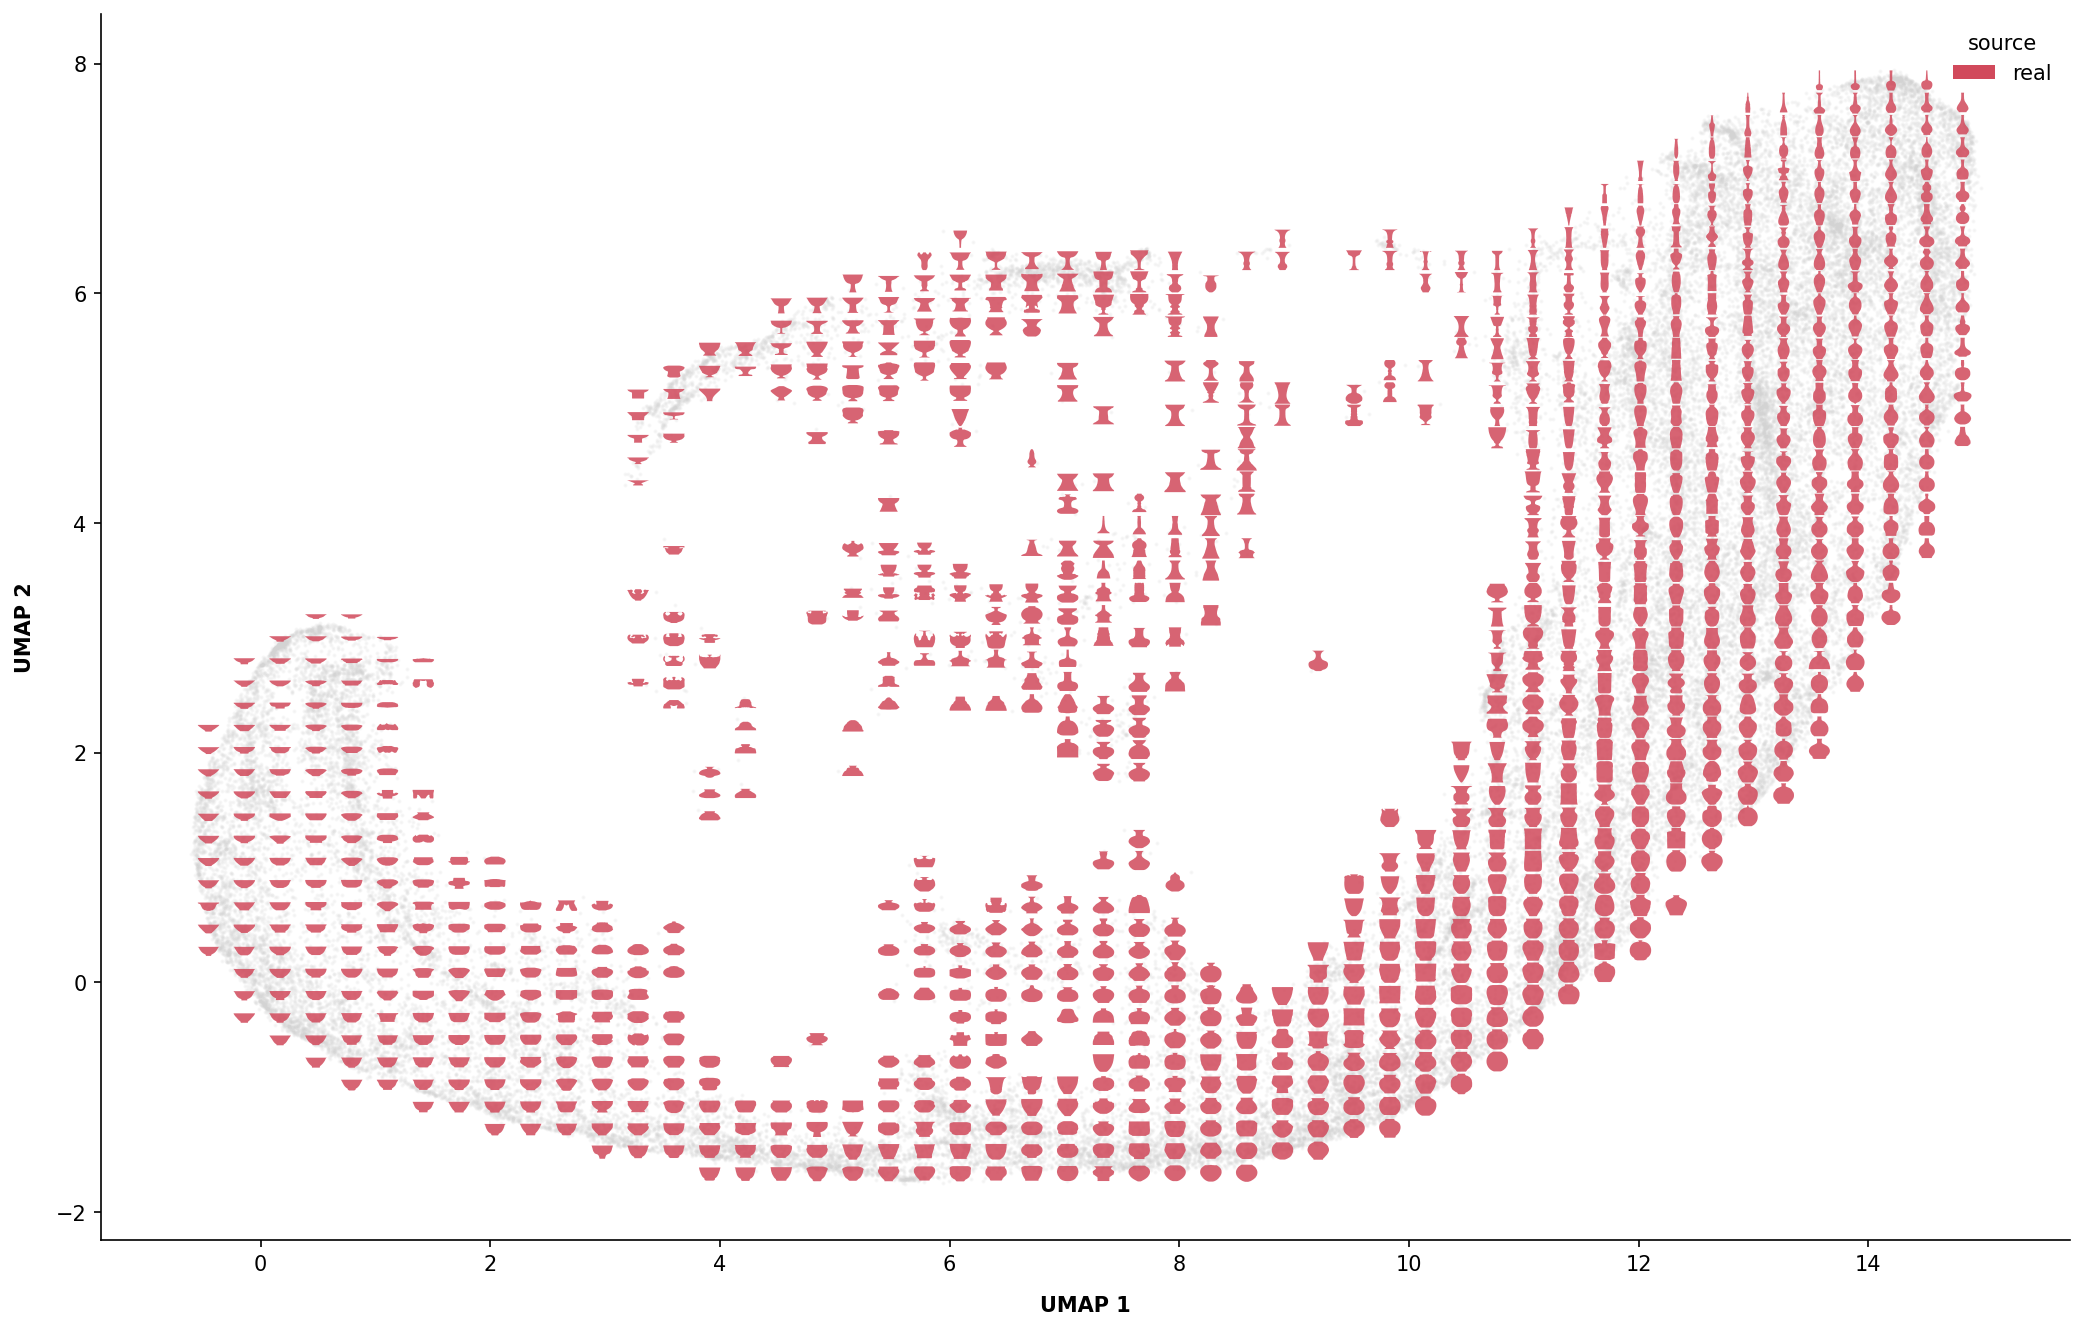

In [62]:
plot_vase_umap_grid(master_df[master_df['source'] == 'real'], contours_by_key, save_path='real_vase_umap_grid.svg')

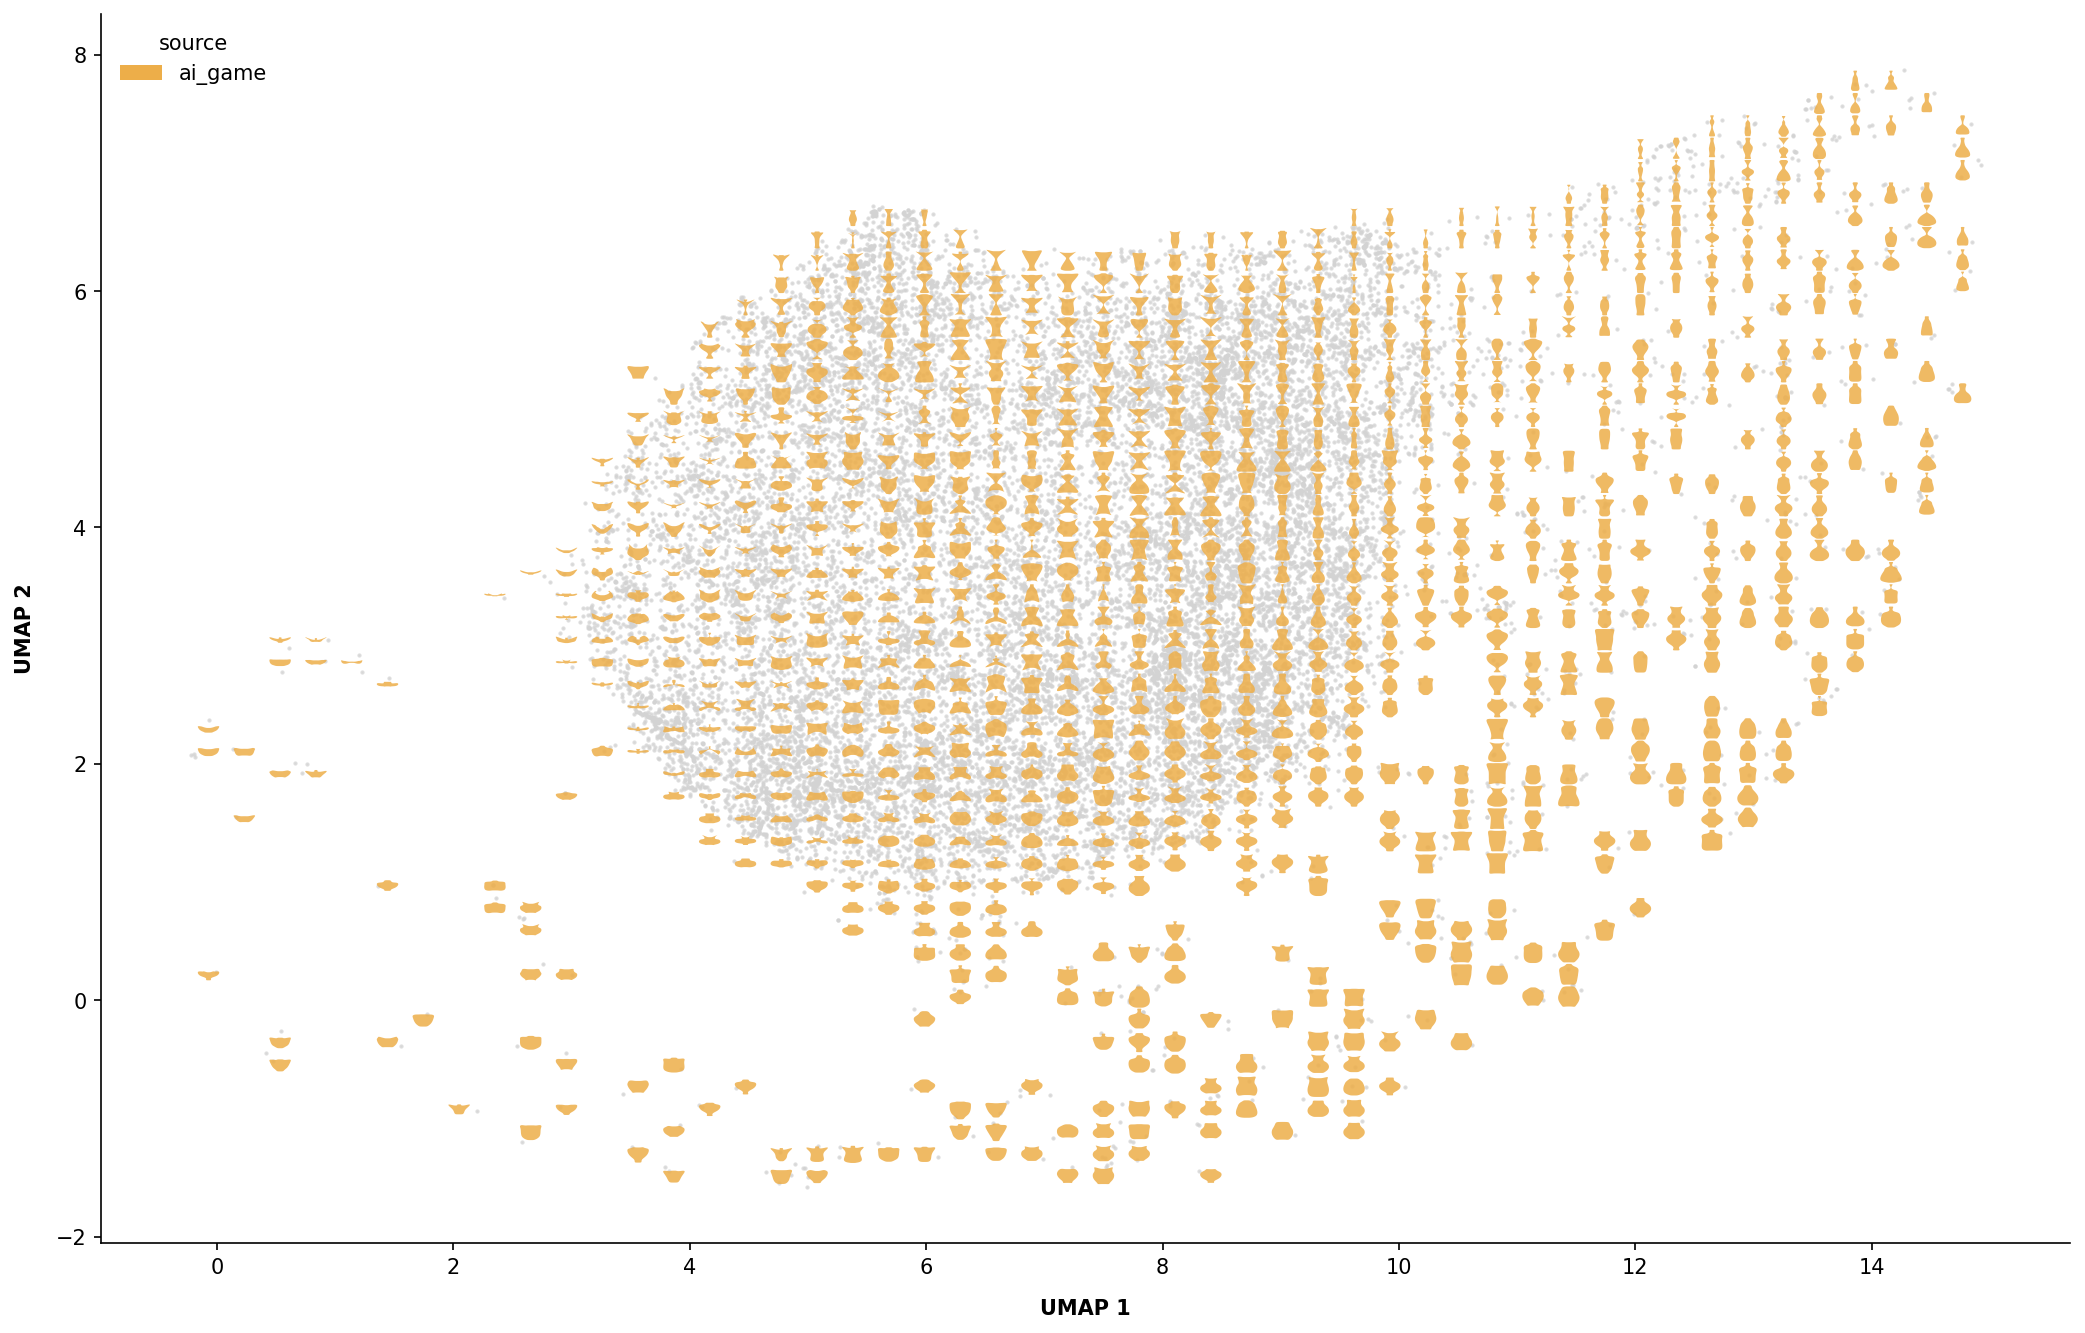

In [63]:
plot_vase_umap_grid(master_df[master_df['source'] == 'ai_game'], contours_by_key, save_path='ai_game_vase_umap_grid.svg')

## 4. Save the UMAP Dataframes

In [64]:
import os

In [65]:
SAVE_DIR = "umap_projections"
REAL_SAVE_PATH = os.path.join(SAVE_DIR, "real_vase_umap_projection.parquet")
GAME_SAVE_PATH = os.path.join(SAVE_DIR, "game_vase_umap_projection.parquet")
MASTER_SAVE_PATH = os.path.join(SAVE_DIR, "combined_vase_umap_projection.parquet")

In [66]:
os.makedirs(SAVE_DIR, exist_ok=True)
master_df.to_parquet(MASTER_SAVE_PATH, index=False)

In [70]:
real_umap_df = master_df[master_df['source'] == 'real']
real_umap_df.drop([col for col in real_umap_df.columns if col.startswith('PC')], axis=1, inplace=True, errors='ignore')
real_umap_df.drop(columns=['source', "generation", "vase", "gen_selected_vase", "elapsed_time", 
                           "ancestral_region", "youth_region", "disability", "user_id", "play_counter", 
                           "round", "user_round_generation", "potter", "age", "gender", "sexuality"], inplace=True, errors='ignore')
real_umap_df.head()

,vase_id,culture_general,generation_key,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,...,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file,umap_x,umap_y
0,af_1,african_subsaharan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.302551,-0.738109
1,af_10,african_subsaharan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.070203,1.833667
2,af_101,african_subsaharan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.110246,6.335219
3,af_102,african_subsaharan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.158931,5.513231
4,af_103,african_subsaharan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.168776,-1.147401


In [71]:
game_umap_df = master_df[master_df['source'] == 'game']
game_umap_df.drop([col for col in game_umap_df.columns if col.startswith('PC')], axis=1, inplace=True, errors='ignore')
game_umap_df.drop(columns=["culture_general", "culture_specific", "continent_made_found", "country_made_found"], inplace=True, errors='ignore')
game_umap_df.head()

,vase_id,source,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,...,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file,umap_x,umap_y
53152,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.427952,5.755923
53153,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.427952,5.755923
53154,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.427952,5.755923
53155,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.427952,5.755923
53156,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.427952,5.755923


In [72]:
ai_umap_df = master_df[master_df['source'] == 'ai_game']
ai_umap_df.drop([col for col in ai_umap_df.columns if col.startswith('PC')], axis=1, inplace=True, errors='ignore')
ai_umap_df.drop(columns=["culture_general", "culture_specific", "continent_made_found", "country_made_found"], inplace=True, errors='ignore')
ai_umap_df.head()

,vase_id,source,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,...,rt_tokens,budget_tokens,budget_utilisation,input_tokens,output_tokens,stop_reason,timestamp,source_file,umap_x,umap_y
537352,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4::round_0_...,ai_game,round_0_gen_1,vase_1,PC1,-3.374880,False,False,NaN,NaN,...,69.0,5000.0,0.0164,1558.0,82.0,completed,2026-05-27T00:06:24.054391,gpt_results.csv.gz,8.045978,2.552755
537353,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4::round_0_...,ai_game,round_0_gen_1,vase_2,PC1,-7.832178,True,False,NaN,NaN,...,69.0,5000.0,0.0164,1558.0,82.0,completed,2026-05-27T00:06:24.054391,gpt_results.csv.gz,9.617061,4.056825
537354,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4::round_0_...,ai_game,round_0_gen_2,vase_1,PC1,-6.031124,False,False,NaN,NaN,...,122.0,5000.0,0.0270,1558.0,135.0,completed,2026-05-27T00:06:26.302597,gpt_results.csv.gz,9.060215,3.468984
537355,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4::round_0_...,ai_game,round_0_gen_2,vase_2,PC1,-7.832178,True,True,NaN,NaN,...,122.0,5000.0,0.0270,1558.0,135.0,completed,2026-05-27T00:06:26.302597,gpt_results.csv.gz,NaN,NaN
537356,5f62ef9d-9dd3-4518-9a1f-548aa38d2ac4::round_0_...,ai_game,round_0_gen_3,vase_1,PC1,-9.644491,False,False,NaN,NaN,...,98.0,5000.0,0.0222,1558.0,111.0,completed,2026-05-27T00:06:28.210096,gpt_results.csv.gz,9.671795,4.529785


In [73]:
real_umap_df.to_parquet(REAL_SAVE_PATH, index=False)
game_umap_df.to_parquet(GAME_SAVE_PATH, index=False)
ai_umap_df.to_parquet(os.path.join(SAVE_DIR, "ai_game_vase_umap_projection.parquet"), index=False)